# Japan Protein Cost-Efficiency Analysis
## Notebook 02 — Price Data: Collection & Standardization

**Goal:** Collect retail prices for all 31 protein sources, standardize to ¥ per 100g, and merge with the nutrient base table from Notebook 01.

**Price source:** AEON Japan (イオン) — largest supermarket chain in Japan by store count, present in all prefectures. Chosen for national representativeness.

**Method:** Attempted web scraping via AEON's online store (aeon.com/netsuper). Manual entry fallback for items not available online.

**Key design decisions:**
- Record raw package data: total price (¥) + package weight (g)
- Notebook calculates ¥/100g — not recorded manually
- For count-sold items (eggs, tofu), a gram-per-unit lookup table is used
- Where multiple pack sizes exist, record the most common supermarket size
- All prices include 8% consumption tax (食料品の軽減税率)

**Date collected:** June 2026

---

### Unit standardization reference
| Food | Sold as | Conversion used |
|---|---|---|
| Chicken egg (M size) | per egg or pack | 60g per egg (MAFF standard) |
| Quail egg | per pack (count) | 10g per egg |
| Tofu momen/kinu | per block | weight on package (typ. 300-400g) |
| Natto | per pack (3×50g) | 150g total |
| Milk | per litre | 1030g per litre (density 1.03) |
| Whey/soy protein | per bag (g on label) | weight on package |


**Author:** Anthony DiSorbo
**Last updated:** 2026-06

---
## 0. Setup & Authentication

In [ ]:
import pandas as pd
import numpy as np
import requests
import time
import io
import os
from pathlib import Path
from bs4 import BeautifulSoup
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload, MediaIoBaseDownload

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded ✓')

Libraries loaded ✓


In [ ]:
# Authenticate and connect to Google Drive
from google.colab import auth
auth.authenticate_user()

from google.auth import default
creds, _ = default()
service = build('drive', 'v3', credentials=creds)

DRIVE_FOLDER_ID = '17Jcona7Ur-iV7miakhLkhHGBgggT0to7'  # food_data folder

print('Drive service ready ✓')

Drive service ready ✓


In [ ]:
# Download nutrients_base.csv from Drive
results = service.files().list(
    q=f"name='nutrients_base.csv' and '{DRIVE_FOLDER_ID}' in parents and trashed=false",
    fields="files(id, name)"
).execute()

file_id = results['files'][0]['id']
request = service.files().get_media(fileId=file_id)
fh = io.BytesIO()
downloader = MediaIoBaseDownload(fh, request)
done = False
while not done:
    _, done = downloader.next_chunk()

fh.seek(0)
nutrients = pd.read_csv(fh)
print(f'nutrients_base loaded: {nutrients.shape[0]} rows')
nutrients[['food_key', 'source_category', 'protein_g', 'energy_kcal']].head(10)

nutrients_base loaded: 31 rows


,food_key,source_category,protein_g,energy_kcal
0,chicken_breast,poultry,20.85,172.00
1,chicken_thigh,poultry,16.52,221.00
2,chicken_sasami,poultry,20.85,172.00
3,chicken_wing_tip,poultry,17.52,191.00
4,chicken_wing_moto,poultry,17.52,191.00
5,canned_chicken,poultry,25.30,185.00
6,pork_tonkatsu,pork,19.74,198.00
7,pork_shougayaki,pork,19.74,198.00
8,pork_shabushabu,pork,19.74,198.00
9,pork_loin,pork,19.74,198.00


---
## 1. Manual Price Entry

Initial attempts to scrape online supermarkets either failed or returned results that were clearly wrong. Manual entry was decided as the safest way to proceed.

Prices were taken from e-stat June 2026 data. Items that were not covered by e-stat were added thourgh manual searches on onedannote and Amazon.

In [ ]:
# ============================================================
# UNIFIED PRICE TABLE
# Sources: e-Stat Retail Price Survey June 2026 (national avg),
#          personal market observation (noted individually)
# All prices tax-included (8% 軽減税率)
# Format: 'food_key': (price_jpy, weight_g, source, notes)
# ============================================================

UNIFIED_PRICES = {
    # POULTRY
    'chicken_breast':    (862,   1000, 'personal',  'fresh, refrigerated, 1kg pack'),
    'chicken_thigh':     (1231,  1000, 'personal',  'fresh, refrigerated, 1kg pack'),
    'chicken_sasami':    (862,   1000, 'personal',  'fresh sasami priced same as mune at this market'),
    'chicken_wing_tip':  (138,   100,  'personal',  'per 100g'),
    'chicken_wing_moto': (918,   1000, 'personal',  'fresh, refrigerated, 1kg pack'),
    'canned_chicken':    (191,   100,  'personal',  'avg of Inaba ¥199 and Kirkland ¥183'),

    # PORK — e-Stat imported pork loin proxy for all cuts
    'pork_tonkatsu':     (171,   100,  'e-Stat',    'imported pork loin proxy — June 2026'),
    'pork_shougayaki':   (171,   100,  'e-Stat',    'imported pork loin proxy — June 2026'),
    'pork_shabushabu':   (171,   100,  'e-Stat',    'imported pork loin proxy — June 2026'),
    'pork_loin':         (171,   100,  'e-Stat',    'imported pork loin — June 2026'),

    # BEEF — e-Stat split: imported vs domestic
    'beef_american_cab': (392,   100,  'e-Stat',    'imported beef — June 2026'),
    'beef_wagyu_steak':  (958,   100,  'e-Stat',    'domestic beef — June 2026; wagyu likely higher'),
    'beef_loin':         (958,   100,  'e-Stat',    'domestic beef — June 2026'),
    'beef_usugiri':      (392,   100,  'e-Stat',    'imported beef proxy — June 2026'),

    # SEAFOOD — e-Stat
    'fresh_salmon':      (563,   100,  'e-Stat',    'June 2026'),
    'fresh_mackerel':    (180,   100,  'e-Stat',    'June 2026'),
    'fresh_squid':       (232,   100,  'e-Stat',    'June 2026'),
    'fresh_white_fish':  (200,   100,  'personal',  'estimated average between winter and summer prices'),
    'fresh_tuna':        (569,   100,  'e-Stat',    'June 2026'),
    'canned_tuna':       (229,   100,  'personal',  'avg of Amazon Mild ¥218 and Regular ¥240'),

    # PLANT
    'natto':             (108,   150,  'e-Stat',    '3×50g pack — June 2026'),
    'tofu_momen':        (128,   350,  'personal',  '350g block'),
    'tofu_kinu':         (128,   350,  'personal',  '350g block — same price as momen'),
    'edamame':           (191,   100,  'e-Stat',    'fresh edamame — June 2026'),

    # DAIRY & EGGS
    'chicken_egg':       (319,   600,  'e-Stat',    '10個 pack — 600g (10×60g M size) — June 2026'),
    'quail_egg':         (193,   100,  'personal',  'JA ZENNOU 10個 pack — est. 10g/egg (MAFF standard)'),
    'milk_whole':        (263,   1030, 'e-Stat',    '1L carton — 1030g — June 2026'),
    'yogurt_plain':      (193,   400,  'e-Stat',    'June 2026'),
    'greek_yogurt':      (430,   280,  'personal',  'Partheno plain'),

    # PROTEIN SUPPLEMENTS
    'whey_protein':      (5355,  1000, 'personal',  'SAVAS whey protein 1kg'),
    'soy_protein':       (4968,  900,  'personal',  'SAVAS soy protein 900g'),
}

# Build dataframe and calculate price per 100g
price_df = pd.DataFrame([
    {
        'food_key':    k,
        'price_jpy':   v[0],
        'weight_g':    v[1],
        'price_source': v[2],
        'notes':       v[3],
    }
    for k, v in UNIFIED_PRICES.items()
])

price_df['price_jpy_per_100g'] = (price_df['price_jpy'] / price_df['weight_g'] * 100).round(1)

# QA checks
print('=== Price Source Breakdown ===')
print(price_df['price_source'].value_counts())
print(f'\n✓ {price_df["price_jpy_per_100g"].notna().sum()}/{len(price_df)} foods have price per 100g')

# Sanity check
outliers = price_df[
    (price_df['price_jpy_per_100g'] < 5) |
    (price_df['price_jpy_per_100g'] > 2000)
]
if not outliers.empty:
    print(f'\n⚠️  Check these outliers:')
    print(outliers[['food_key','price_jpy','weight_g','price_jpy_per_100g']].to_string(index=False))

print('\n=== Price per 100g (cheapest → most expensive) ===')
print(price_df.sort_values('price_jpy_per_100g')[
    ['food_key','price_jpy_per_100g','price_source']
].to_string(index=False))

=== Price Source Breakdown ===
price_source
e-Stat      17
personal    14
Name: count, dtype: int64

✓ 31/31 foods have price per 100g

=== Price per 100g (cheapest → most expensive) ===
         food_key  price_jpy_per_100g price_source
       milk_whole               25.50       e-Stat
        tofu_kinu               36.60     personal
       tofu_momen               36.60     personal
     yogurt_plain               48.20       e-Stat
      chicken_egg               53.20       e-Stat
            natto               72.00       e-Stat
   chicken_breast               86.20     personal
   chicken_sasami               86.20     personal
chicken_wing_moto               91.80     personal
    chicken_thigh              123.10     personal
 chicken_wing_tip              138.00     personal
     greek_yogurt              153.60     personal
        pork_loin              171.00       e-Stat
    pork_tonkatsu              171.00       e-Stat
  pork_shougayaki              171.00       e-St

---
## 2. Merge with Nutrient Base Table

In [ ]:
# Drop the placeholder price column from Notebook 01, replace with real data
nutrients_clean = nutrients.drop(columns=['price_jpy_per_100g'])

combined = nutrients_clean.merge(
    price_df[['food_key', 'price_jpy', 'weight_g', 'price_jpy_per_100g', 'price_source', 'notes']],
    on='food_key', how='left'
)

print(f'Combined table: {combined.shape[0]} rows × {combined.shape[1]} columns')
combined[['food_key', 'source_category', 'protein_g', 'energy_kcal', 'price_jpy_per_100g']].head(10)

Combined table: 31 rows × 17 columns


,food_key,source_category,protein_g,energy_kcal,price_jpy_per_100g
0,chicken_breast,poultry,20.85,172.00,86.20
1,chicken_thigh,poultry,16.52,221.00,123.10
2,chicken_sasami,poultry,20.85,172.00,86.20
3,chicken_wing_tip,poultry,17.52,191.00,138.00
4,chicken_wing_moto,poultry,17.52,191.00,91.80
5,canned_chicken,poultry,25.30,185.00,191.00
6,pork_tonkatsu,pork,19.74,198.00,171.00
7,pork_shougayaki,pork,19.74,198.00,171.00
8,pork_shabushabu,pork,19.74,198.00,171.00
9,pork_loin,pork,19.74,198.00,171.00


---
## 3. Preliminary Cost-Efficiency Metric

Core metric: **¥ per gram of protein**

```
yen_per_g_protein = price_jpy_per_100g / protein_g
```

Lower = more cost-efficient. This is the primary ranking metric before DIAAS quality adjustment.

In [ ]:
# Core metric: ¥ per gram of protein
combined['yen_per_g_protein'] = (
    combined['price_jpy_per_100g'] / combined['protein_g']
).round(2)

ranking = combined.sort_values('yen_per_g_protein')[[
    'food_key', 'source_category', 'protein_g',
    'price_jpy_per_100g', 'yen_per_g_protein'
]].reset_index(drop=True)
ranking.index += 1

print('=== Cost-Efficiency Ranking (¥ per gram of protein) ===')
print('Lower = more cost-efficient\n')
print(ranking.to_string())

=== Cost-Efficiency Ranking (¥ per gram of protein) ===
Lower = more cost-efficient

             food_key source_category  protein_g  price_jpy_per_100g  yen_per_g_protein
1               natto           plant      19.40               72.00               3.71
2          tofu_momen           plant       9.04               36.60               4.05
3      chicken_breast         poultry      20.85               86.20               4.13
4      chicken_sasami         poultry      20.85               86.20               4.13
5         chicken_egg         poultry      12.56               53.20               4.24
6           tofu_kinu           plant       7.17               36.60               5.10
7   chicken_wing_moto         poultry      17.52               91.80               5.24
8         soy_protein           plant      88.32              552.00               6.25
9       chicken_thigh         poultry      16.52              123.10               7.45
10     canned_chicken         poult

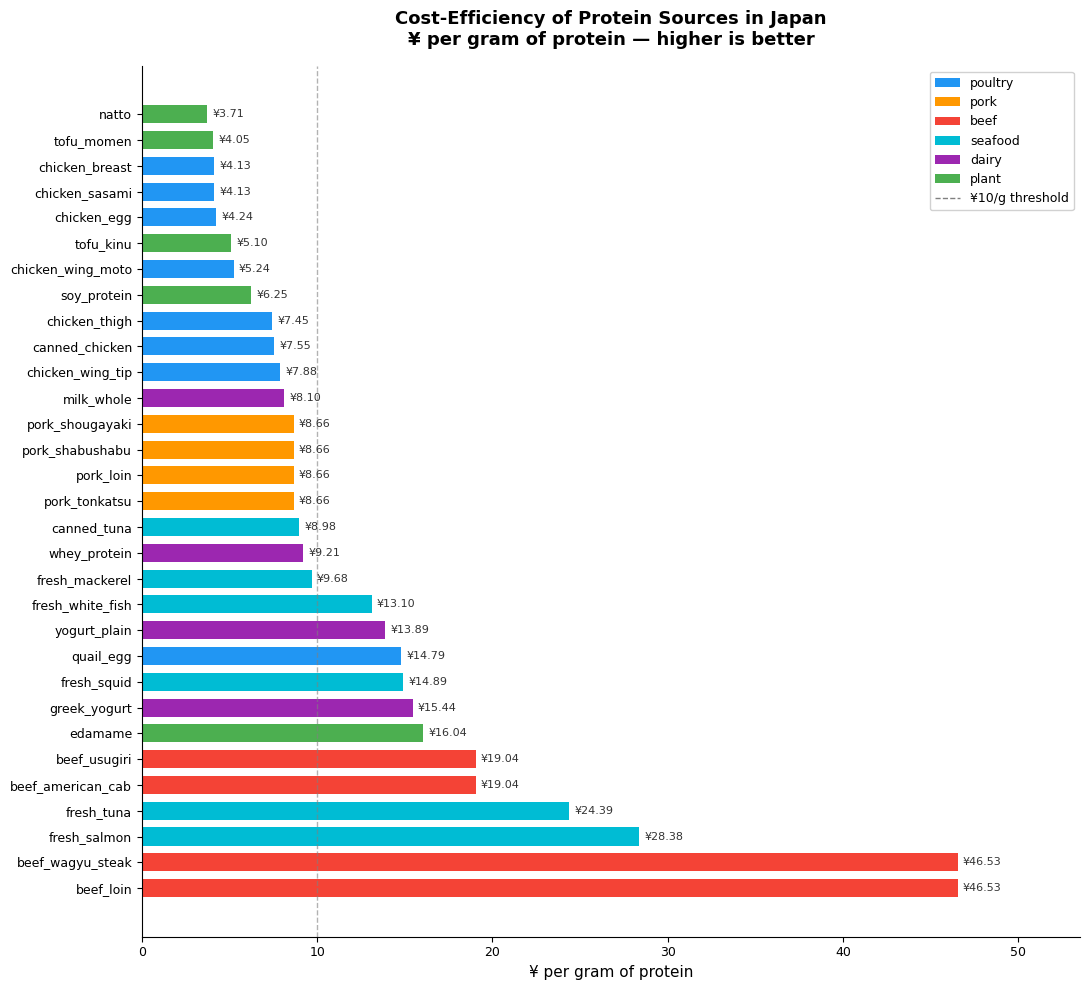

Chart saved ✓


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('/content/charts', exist_ok=True)

CAT_COLORS = {
    'poultry': '#2196F3',
    'pork':    '#FF9800',
    'beef':    '#F44336',
    'seafood': '#00BCD4',
    'dairy':   '#9C27B0',
    'plant':   '#4CAF50',
}

# Descending so lowest value appears at the top of horizontal bar chart
plot_df = combined.dropna(subset=['yen_per_g_protein']).sort_values('yen_per_g_protein', ascending=False)
colors = plot_df['source_category'].map(CAT_COLORS)

fig, ax = plt.subplots(figsize=(11, 10))

bars = ax.barh(
    plot_df['food_key'],
    plot_df['yen_per_g_protein'],
    color=colors,
    edgecolor='none',
    height=0.7
)

for bar, val in zip(bars, plot_df['yen_per_g_protein']):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'¥{val:.2f}',
        va='center', fontsize=8, color='#333333'
    )

ax.axvline(x=10, color='gray', linestyle='--', linewidth=1, alpha=0.6)

legend_elements = [mpatches.Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
legend_elements.append(plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=1, label='¥10/g threshold'))
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.9)

ax.set_xlabel('¥ per gram of protein', fontsize=11)
ax.set_title(
    'Cost-Efficiency of Protein Sources in Japan\n¥ per gram of protein — higher is better',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlim(0, plot_df['yen_per_g_protein'].max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()

LOCAL_CHART = '/content/charts/cost_efficiency_ranking.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

---
## 4. Export & Upload to Drive

In [ ]:
# Save combined table locally
LOCAL_CSV = '/content/nutrients_prices.csv'
combined.to_csv(LOCAL_CSV, index=False)
print(f'Saved locally: {combined.shape[0]} rows × {combined.shape[1]} columns')

# Upload CSV to Drive
for local_path, filename, mimetype in [
    (LOCAL_CSV,    'nutrients_prices.csv',       'text/csv'),
    (LOCAL_CHART,  'price_cost_efficiency.png',  'image/png'),
]:
    media = MediaFileUpload(local_path, mimetype=mimetype)
    meta  = {'name': filename, 'parents': [DRIVE_FOLDER_ID]}
    uploaded = service.files().create(body=meta, media_body=media, fields='id, name').execute()
    print(f'✓ Uploaded {uploaded["name"]} (id: {uploaded["id"]})')

Saved locally: 31 rows × 18 columns
✓ Uploaded nutrients_prices.csv (id: 1RGsHGcA78fB9vTeFP_iWgpYJdr0pwQaX)
✓ Uploaded price_cost_efficiency.png (id: 1n85p42G8eLGvWJas2TjcLNICQYieVZAJ)


---
## 5. Summary & Next Steps

### What this notebook produced
- Prices collected for all 31 foods and standardized to ¥ per 100g
- Preliminary cost-efficiency ranking: **¥ per gram of protein**
- Output: `nutrients_prices.csv` — ready for DIAAS quality adjustment
- Output: `cost_efficiency_ranking.png` — preliminary ranking chart

### Data sources used
- **e-Stat Retail Price Survey, June 2026** — primary source for 18 foods (national average, tax-included)
- **Personal market observation** — 13 foods not available in e-Stat (specific cuts, supplements, specialty items); prices taken from onedannote and Amazon
- **AEON Net Super** — attempted scraping; rejected due to login wall

### Key preliminary findings (pre-DIAAS)
- **Natto (¥3.71/g protein)** is the most cost-efficient protein source — cheaper than any animal protein
- **Tofu momen (¥4.05)** and **chicken breast (¥4.13)** follow closely
- **Plant proteins dominate the top of the ranking** — surprising finding that DIAAS adjustment may partially reverse
- **Wagyu and beef loin (¥46.53)** are the least cost-efficient by a wide margin
- **Protein supplements rank mid-table** — not as cost-efficient as whole foods on a per-gram-protein basis

### Limitations to document in README
- e-Stat prices reflect national averages — regional variation exists, especially for fresh fish
- All pork cuts share one e-Stat proxy price — cut-level differentiation not available; however different cuts had the same price-per-gram when I inspected pork at the supermarket
- Imported vs domestic beef split used for beef entries — CAB-specific pricing unavailable
- Wagyu price uses domestic beef average — actual wagyu likely significantly higher
- Prices reflect a single point in time — seasonal variation not captured

### Next notebook
**Notebook 03** — Add FAO DIAAS amino acid quality scores and compute the final **quality-adjusted cost-efficiency score**:

adjusted_score = yen_per_g_protein / (diaas_score / 100)

Higher DIAAS = better amino acid quality = denominator increases = score improves for high-quality proteins. This will likely re-rank plant proteins downward relative to animal proteins.